# 14 — Jev patterns without a key: confidence-gated routing + decision-in-state

The live Jev API is waitlisted, so the integration work continues with the
mock router — the `JevAdapter` already has the exact typed interface of the
real model, so when `TYPESAFE_API_KEY` arrives this notebook runs live
unchanged.

This notebook implements the two patterns from the Jev guide that matter for
ewm-sm:

1. **Confidence-gated routing (Pattern 2).** When Jev's confidence is below a
   floor, the query is routed to a safe fallback LLM instead of Jev's first
   choice. The floor is per-action policy, not a global threshold.
2. **Decision-in-state.** The `DecisionRecord` is lowered into `tid`-style
   tokens (`jev_choice_llm_b`, `jev_conf_4`, `jev_p_llm_a_31`, …) and
   ingested into the union frame, so the decision itself becomes part of
   `S(t)` and of the materialized memory — the system remembers not just what
   was answered, but who was chosen and how confidently.

In [1]:
import os, sys, json

os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    EwmScene,
    JevAdapter,
    LlmAdapter,
    run_open_loop,
    run_jev_loop,
)

WORK = "/home/alexmy/.cache/ewm-multi-llm-jev14"
os.makedirs(WORK, exist_ok=True)
ewm = EwmScene()
print("ewm-scene:", ewm.bin)
print("work:", WORK)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene
work: /home/alexmy/.cache/ewm-multi-llm-jev14


In [2]:
QUERIES = [
    "What is the capital of France?",
    "Explain gravity in one sentence.",
    "Write a haiku about rain.",
    "What is the meaning of life?",
    "Name three planets in our solar system.",
    "What is the speed of light?",
    "Define entropy in simple words.",
    "Who wrote Romeo and Juliet?",
]

adapter = LlmAdapter()
jev = JevAdapter()                     # mock until TYPESAFE_API_KEY is set
print("adapter names:", adapter.names)
print("Jev mode:", "mock" if jev.mock else "real API")

adapter names: ('llm_a', 'llm_b', 'llm_c')
Jev mode: mock


## §1 — Open loop: the shared context (same as notebooks 09–13)

In [3]:
open_result = run_open_loop(adapter, ewm, QUERIES, WORK, cycles=3, max_new_tokens=48)
print("IICA (union discovered twice):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape, "| prototypes:", open_result.M_proto.shape)
print("DFT-detected period:", open_result.period, "steps (true period 8)")

IICA (union discovered twice): True
BSS trajectory: (24, 3) | prototypes: (8, 3)
DFT-detected period: 8.0 steps (true period 8)


## §2 — Two router loops, same floor, one difference

- **Loop A** — confidence-gated routing only (`ingest_decision=False`).
- **Loop B** — the same, plus the decision ingested into `S(t)`
  (`ingest_decision=True`).

Both use `confidence_floor=0.45` with `fallback="llm_b"`: below the floor,
the general instruct LLM answers instead of Jev's first choice.

In [4]:
floor = 0.45
fallback = "llm_b"

loop_a = run_jev_loop(
    adapter, jev, ewm, open_result, QUERIES, f"{WORK}/no_decision",
    T=16, max_new_tokens=48,
    confidence_floor=floor, fallback=fallback, ingest_decision=False,
)

decisions_a = loop_a.decision_log
print()
print("loop A (routing only):")
print("  gated steps:", sum(loop_a.gated_log), "of", len(loop_a.gated_log))
print("  decision distribution:",
      {n: sum(1 for d in decisions_a if d.decision == n) for n in adapter.names})

t= 0 q=0  route=llm_a   confidence=0.476  gated=False  mock=True
t= 4 q=4  route=llm_b   confidence=0.420  gated=True  mock=True
t= 8 q=0  route=llm_b   confidence=0.406  gated=True  mock=True
t=12 q=4  route=llm_b   confidence=0.420  gated=True  mock=True
t=15 q=7  route=llm_b   confidence=0.374  gated=True  mock=True

loop A (routing only):
  gated steps: 11 of 16
  decision distribution: {'llm_a': 1, 'llm_b': 7, 'llm_c': 8}


In [5]:
loop_b = run_jev_loop(
    adapter, jev, ewm, open_result, QUERIES, f"{WORK}/decision",
    T=16, max_new_tokens=48,
    confidence_floor=floor, fallback=fallback, ingest_decision=True,
)

decisions_b = loop_b.decision_log
print()
print("loop B (routing + decision-in-state):")
print("  gated steps:", sum(loop_b.gated_log), "of", len(loop_b.gated_log))
print("  decision distribution:",
      {n: sum(1 for d in decisions_b if d.decision == n) for n in adapter.names})

# The decision is now part of S(t): the union frame carries jev_* tokens.
last_frame = json.loads(open(loop_b.union_path).readlines()[-1])
jev_tokens = [t for t in last_frame["tokens"] if t.startswith("jev_")]
print("  jev tokens in the last union frame:", jev_tokens[:12], "...")
print("  total tokens in last union frame:", len(last_frame["tokens"]))

t= 0 q=0  route=llm_a   confidence=0.476  gated=False  mock=True
t= 4 q=4  route=llm_a   confidence=0.453  gated=False  mock=True
t= 8 q=0  route=llm_b   confidence=0.417  gated=True  mock=True
t=12 q=4  route=llm_b   confidence=0.428  gated=True  mock=True
t=15 q=7  route=llm_b   confidence=0.469  gated=False  mock=True

loop B (routing + decision-in-state):
  gated steps: 13 of 16
  decision distribution: {'llm_a': 6, 'llm_b': 6, 'llm_c': 4}
  jev tokens in the last union frame: ['jev_choice_llm_b', 'jev_conf_5', 'jev_p_llm_a_27', 'jev_p_llm_b_47', 'jev_p_llm_c_27', 'jev_needs_memory_5'] ...
  total tokens in last union frame: 54


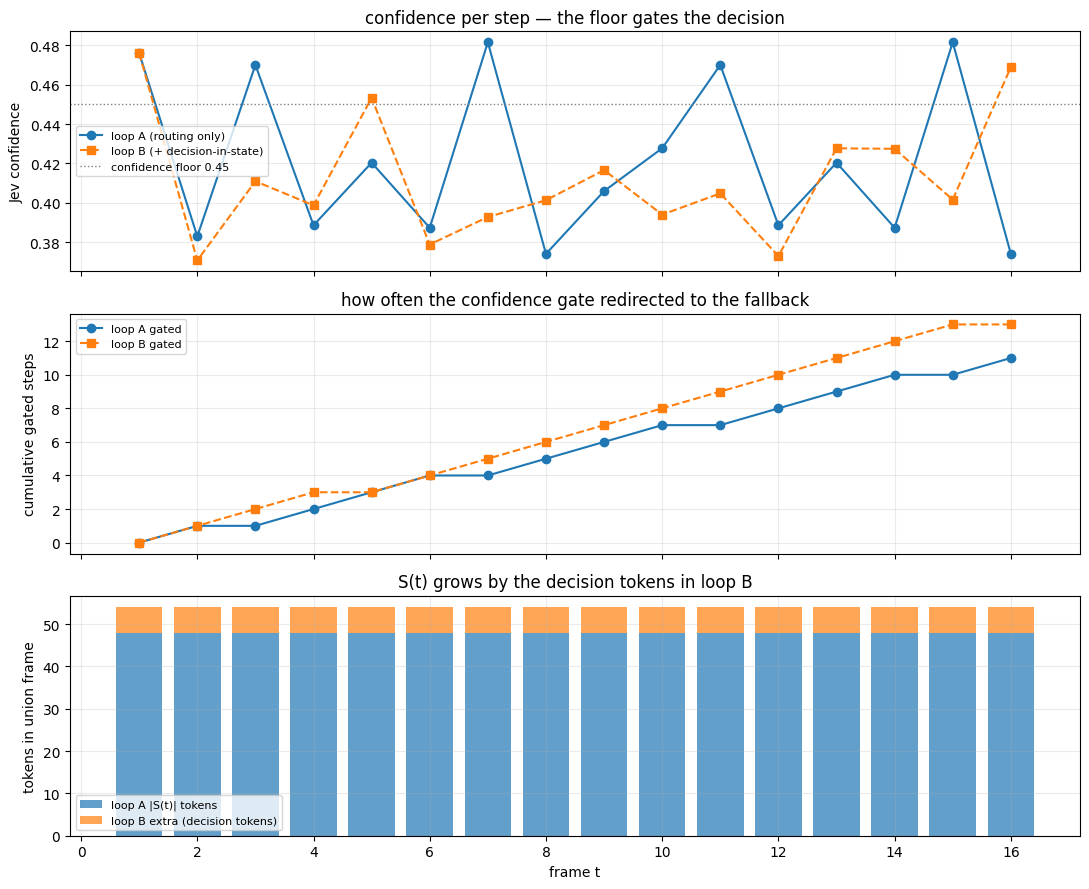

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

names = list(adapter.names)
T = len(loop_b.decision_log)
t_axis = np.arange(1, T + 1)
conf_a = [d.confidence for d in loop_a.decision_log]
conf_b = [d.confidence for d in loop_b.decision_log]

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(t_axis, conf_a, "o-", label="loop A (routing only)")
axes[0].plot(t_axis, conf_b, "s--", label="loop B (+ decision-in-state)")
axes[0].axhline(floor, color="gray", ls=":", lw=1.0, label=f"confidence floor {floor}")
axes[0].set_ylabel("Jev confidence")
axes[0].set_title("confidence per step — the floor gates the decision")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, [sum(loop_a.gated_log[:i+1]) for i in range(T)],
             "o-", label="loop A gated")
axes[1].plot(t_axis, [sum(loop_b.gated_log[:i+1]) for i in range(T)],
             "s--", label="loop B gated")
axes[1].set_ylabel("cumulative gated steps")
axes[1].set_title("how often the confidence gate redirected to the fallback")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

pop_a = []
pop_b = []
for i in range(T):
    fa = json.loads(open(loop_a.union_path).readlines()[i])
    fb = json.loads(open(loop_b.union_path).readlines()[i])
    pop_a.append(len(fa["tokens"]))
    pop_b.append(len(fb["tokens"]))
axes[2].bar(t_axis, pop_a, alpha=0.7, label="loop A |S(t)| tokens")
axes[2].bar(t_axis, [b - a for a, b in zip(pop_a, pop_b)], bottom=pop_a,
            alpha=0.7, color="tab:orange", label="loop B extra (decision tokens)")
axes[2].set_ylabel("tokens in union frame")
axes[2].set_xlabel("frame t")
axes[2].set_title("S(t) grows by the decision tokens in loop B")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/jev_patterns.png", dpi=110)
plt.show()

## Summary

- **Confidence-gated routing works**: below `confidence_floor=0.45` the
  controller routes to the fallback `llm_b`; the gate count is logged per
  step and visible in the trajectory.
- **Decision-in-state works**: in loop B every union frame carries
  `jev_*` tokens, so `S(t)` includes the decision itself, and the
  materialized memory now remembers not just the answer but *who was chosen
  and how confidently*.
- Nothing in ewm-sm changed — the decision tokens go through the exact same
  ingest/materialize path as LLM tokens.
- When `TYPESAFE_API_KEY` arrives, the same notebook runs live; the only
  difference is `mock=False` and real calibrated confidences.

Next: use Jev's `Score` and `Noul` primitives to gate per-action confidence
(e.g., escalate to all three LLMs when `needs_memory` is high), and feed the
decision probabilities into the selector as extra soft-state dimensions.